Dataset Preview:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Dataset Shape: (20640, 9)

Model Comparison
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732

Best Model: Decision Tree


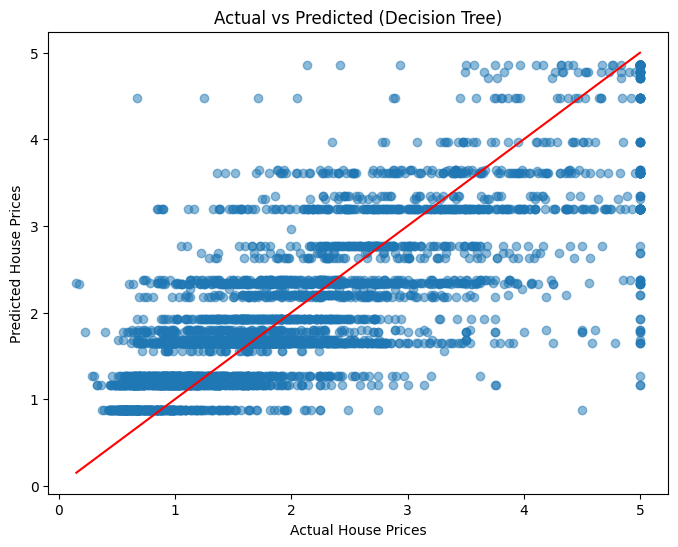


Feature Importance:
MedInc        0.771212
AveOccup      0.128407
HouseAge      0.041621
AveRooms      0.031261
Latitude      0.022049
Population    0.002485
Longitude     0.002097
AveBedrms     0.000869
dtype: float64


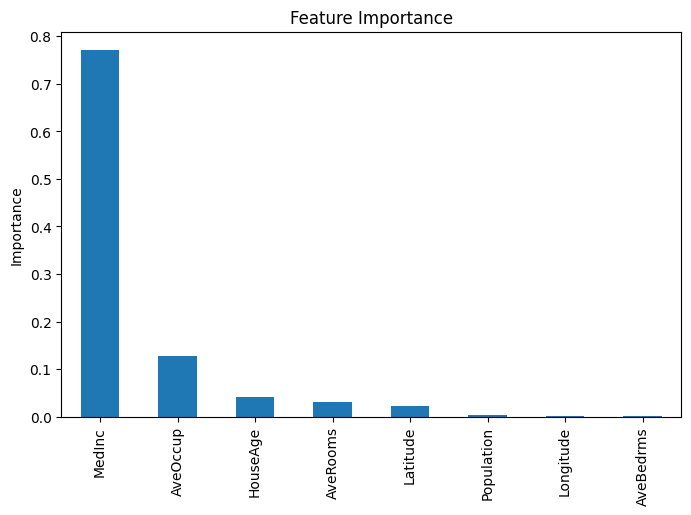


Best model saved successfully!


In [1]:
# ==========================================
# AI/ML TASK 2 - Model Comparison Project
# California Housing Dataset
# ==========================================

# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# Step 2: Load Dataset
# ==========================================

# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)

# Combine features and target into one dataframe
df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

# Display first 5 rows
print("Dataset Preview:")
print(df.head())

# Dataset information
print("\nDataset Shape:", df.shape)

# ==========================================
# Step 3: Separate Features and Target
# ==========================================

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# ==========================================
# Step 4: Feature Scaling
# ==========================================

scaler = StandardScaler()

# Scale all feature columns
X_scaled = scaler.fit_transform(X)

# ==========================================
# Step 5: Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# Step 6: Define Models
# ==========================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

# ==========================================
# Step 7: Train and Evaluate Models
# ==========================================

results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    predictions = model.predict(X_test)

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    # R² Score
    r2 = r2_score(y_test, predictions)

    # Store results
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Convert to dataframe
results_df = pd.DataFrame(results).T

print("\nModel Comparison")
print(results_df)

# ==========================================
# Step 8: Select Best Model
# ==========================================

best_model_name = results_df["R2 Score"].idxmax()

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# ==========================================
# Step 9: Actual vs Predicted Plot
# ==========================================

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted ({best_model_name})")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

# ==========================================
# Step 10: Feature Importance
# (Decision Tree Only)
# ==========================================

if "Decision Tree" in models:

    tree_model = models["Decision Tree"]

    importance = pd.Series(
        tree_model.feature_importances_,
        index=X.columns
    )

    importance = importance.sort_values(
        ascending=False
    )

    print("\nFeature Importance:")
    print(importance)

    plt.figure(figsize=(8, 5))
    importance.plot(kind="bar")
    plt.title("Feature Importance")
    plt.ylabel("Importance")
    plt.show()

# ==========================================
# Step 11: Save Best Model (Optional)
# ==========================================

import joblib

joblib.dump(best_model, "best_house_price_model.pkl")

print("\nBest model saved successfully!")